# Cyberbullying Detection using Machine Learning

## Objective
Build and evaluate models to classify types of cyberbullying.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV,\
                                    train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score,\
                            classification_report, confusion_matrix, ConfusionMatrixDisplay,\
                            roc_curve, auc, precision_recall_curve

from sklearn.preprocessing import label_binarize
import xgboost as xgb

from sklearn.preprocessing import LabelEncoder

In [2]:
df= pd.read_csv("/content/cyberbullying_tweets.csv")

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_text          47692 non-null  object
 1   cyberbullying_type  47692 non-null  object
dtypes: object(2)
memory usage: 745.3+ KB


,tweet_text,cyberbullying_type
count,47692,47692
unique,46017,6
top,MARINATED IN GATER TEARS,religion
freq,2,7998


## Data Cleaning


In [6]:
df = df.drop_duplicates()
df.groupby("cyberbullying_type").count()

,tweet_text
cyberbullying_type,
age,7992
ethnicity,7959
gender,7948
not_cyberbullying,7937
other_cyberbullying,7823
religion,7997


In [ ]:
df.isna().sum()

,0
tweet_text,0
cyberbullying_type,0


## Data Transformation

In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'@\w+', '', text)                  # remove mentions
    text = re.sub(r'http\S+|www\S+', '', text)        # remove urls
    text = re.sub(r'#', '', text)                     # remove hashtag symbol
    text = re.sub(r'[^\w\s]', '', text)               # remove punctuation
    text = re.sub(r'\d+', '', text)                   # remove numbers
    text = re.sub(r'\s+', ' ', text).strip()          # remove extra spaces
    return text


In [8]:
df["tweet_text"] = df["tweet_text"].apply(clean_text)

/tmp/ipykernel_14494/2743439640.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["tweet_text"] = df["tweet_text"].apply(clean_text)


In [9]:
df

,tweet_text,cyberbullying_type
0,in other words katandandre your food was crapi...,not_cyberbullying
1,why is aussietv so white mkr theblock imaceleb...,not_cyberbullying
2,a classy whore or more red velvet cupcakes,not_cyberbullying
3,meh p thanks for the heads up but not too conc...,not_cyberbullying
4,this is an isis account pretending to be a kur...,not_cyberbullying
...,...,...
47687,black ppl arent expected to do anything depend...,ethnicity
47688,turner did not withhold his disappointment tur...,ethnicity
47689,i swear to god this dumb nigger bitch i have g...,ethnicity
47690,yea fuck you rt if youre a nigger fucking unfo...,ethnicity


I use TF-IDF vectorization to convert text into numerical features.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(df["tweet_text"], df["cyberbullying_type"], test_size=0.2, random_state=42, stratify=df['cyberbullying_type'])

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.17647,
    random_state=42,
    stratify=y_train
)


tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)


In [12]:
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

## Logistic Regression

### Model Training

In [ ]:
model = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
model.fit(X_train_tfidf, y_train)

pred = model.predict(X_val_tfidf)
proba = model.predict_proba(X_val_tfidf)

recall = recall_score(y_val, pred, average="macro")
precision = precision_score(y_val, pred, average="macro")
f1 = f1_score(y_val, pred, average="macro")
roc_auc = roc_auc_score(y_val_enc, proba, multi_class="ovr", average="macro")
recall, precision, f1, roc_auc.item()

(0.8204525821386607,
 0.8254529045130056,
 0.8215190400610238,
 0.9654322585861609)

### Hyperparameter Tuning

I want to perform hyperparameter tuning of LogisticRegression usign GridSearchCV.

In [ ]:
logres = LogisticRegression(class_weight="balanced", random_state=42)

param_grid = {
    "max_iter": [1000, 1500, 2000, 2500]
}

grid= GridSearchCV(
    estimator=logres,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X_train_tfidf, y_train_enc)
print(grid.best_params_)
print(grid.best_score_)
print(grid.best_estimator_)

{'max_iter': 1000}
0.8190041304900826
LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


Grid Search cross-validation 5 folds returned that the best max_iter for LogisticRegression where it is equal to 1000.

### Evaluation (metrics + plots)


Since I got the best model I would like to test it.

In [14]:
target_labels = list(df["cyberbullying_type"].unique())
# best_logres = grid.best_estimator_
best_logres = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)

best_logres.fit(X_train_tfidf, y_train_enc)
y_pred = best_logres.predict(X_val_tfidf)

log_res = classification_report(y_val_enc, y_pred, target_names=target_labels)
print(log_res)

                     precision    recall  f1-score   support

  not_cyberbullying       0.97      0.97      0.97      1128
             gender       0.98      0.98      0.98      1124
           religion       0.91      0.80      0.85      1122
other_cyberbullying       0.58      0.53      0.56      1121
                age       0.58      0.68      0.62      1104
          ethnicity       0.94      0.96      0.95      1129

           accuracy                           0.82      6728
          macro avg       0.83      0.82      0.82      6728
       weighted avg       0.83      0.82      0.82      6728



We see that the model struggles to predict correctly cyberbullying based on age and other types. Such low recall indicated that model mises amny true positives and low precision that a lot of false positives in predictions.

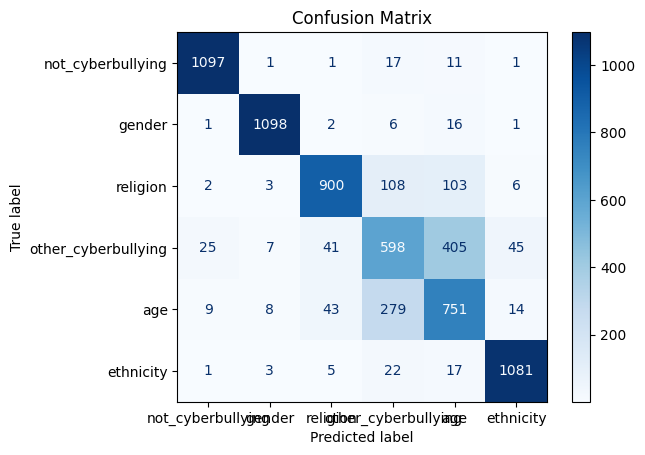

In [15]:
cm = confusion_matrix(y_val_enc, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_labels)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.show()

So the confusion maxtrix clearly shows us where the model struggles a lot, that proves the point about the classification report table.

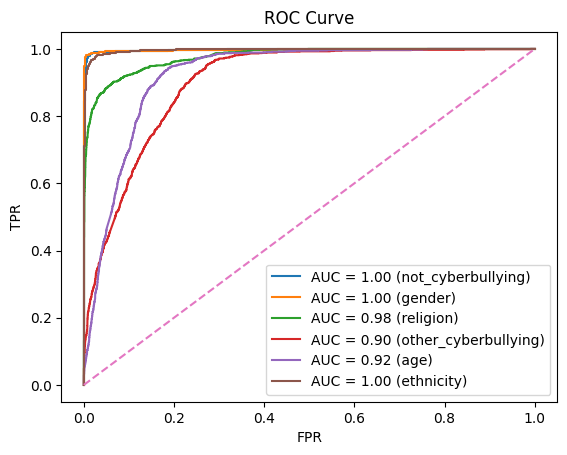

In [42]:
classes = list(set(y_val_enc))
y_bin = label_binarize(y_val_enc, classes=classes)
y_pred = best_logres.predict_proba(X_val_tfidf)

for i in range(len(classes)):
  fpr, tpr, _ = roc_curve(y_bin[:, i], y_pred[:, i])
  roc_auc = auc(fpr, tpr)
  plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f} ({target_labels[i]})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

The ROC AUC curve shows a good result, however we should not depend on it a lot because does not measure classification errors. The model may know which samples are likely positive but may misclassify at the chosen threshold.

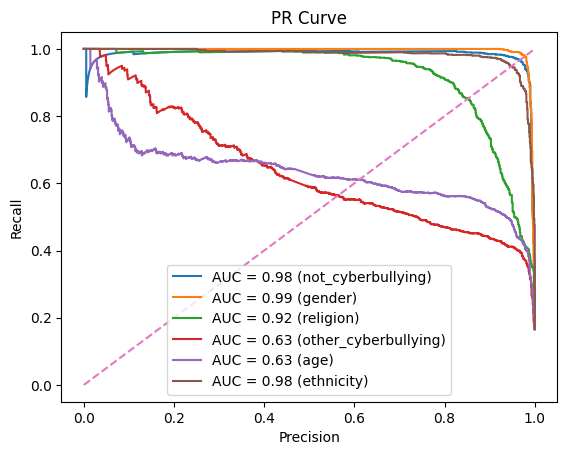

In [43]:
for i in range(len(classes)):
  precision, recall, _ = precision_recall_curve(y_bin[:, i], y_pred[:, i])
  pr_auc = auc(recall, precision)
  plt.plot(recall, precision, label=f"AUC = {pr_auc:.2f} ({target_labels[i]})")


plt.plot([0,1],[0,1],'--')
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.title("PR Curve")
plt.legend()
plt.show()

PR curve shows better what classes are actually weak and it is because it focuses on precision and recall, which directly reflect real classification performance. The age and other cyberbullying classes showed substantially lower PR-AUC scores (0.63 and 0.63), indicating poor precision and higher false positive rates.

## XGBoost

### Model Training

In [ ]:
xgbc = xgb.XGBClassifier(n_estimators=200, max_depth=4)
xgbc.fit(X_train_tfidf, y_train_enc)

pred = xgbc.predict(X_val_tfidf)
proba = xgbc.predict_proba(X_val_tfidf)

recall = recall_score(y_val_enc, pred, average="macro")
precision = precision_score(y_val_enc, pred, average="macro")
f1 = f1_score(y_val_enc, pred, average="macro")
roc_auc = roc_auc_score(y_val_enc, proba, multi_class="ovr", average="macro")

recall, precision, f1, roc_auc.item()

(0.8276550188779835,
 0.8386027074296839,
 0.8292169799912418,
 0.9687389646837032)

### Hyperparameter Tuning

In [ ]:
xgbc = xgb.XGBClassifier()

param_dist = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200]
}

random_search = RandomizedSearchCV(
    estimator=xgbc,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train_tfidf, y_train_enc)

print(random_search.best_params_)
print(random_search.best_score_)
print(random_search.best_estimator_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


{'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.1}
nan
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)


Random Search cross-validation with 10 iterations and 5 folds returned that the best XGBClassifier model is the one with 100 n_estimators, 7 max_depth and 0.1 learning_rate.

### Evaluation (metrics + plots)

In [45]:
target_labels = list(df["cyberbullying_type"].unique())
# best_xgbc = grid2.best_estimator_
best_xgbc = xgb.XGBClassifier(n_estimators=100, max_depth=7, learning_rate=0.1, random_state=42)

best_xgbc.fit(X_train_tfidf, y_train_enc)
y_pred = best_xgbc.predict(X_val_tfidf)

log_res = classification_report(y_val_enc, y_pred, target_names=target_labels)
print(log_res)

                     precision    recall  f1-score   support

  not_cyberbullying       0.99      0.97      0.98      1128
             gender       0.99      0.98      0.98      1124
           religion       0.92      0.80      0.86      1122
other_cyberbullying       0.67      0.44      0.53      1121
                age       0.55      0.84      0.66      1104
          ethnicity       0.96      0.94      0.95      1129

           accuracy                           0.83      6728
          macro avg       0.85      0.83      0.83      6728
       weighted avg       0.85      0.83      0.83      6728



IN comparison to the logistic regression, XGBClassifier's metrics on age show an improvement  in recall and f1 score, however when it comes to other types of cyberbullying both recall and f1-score show worse performance while only precision shows increase.

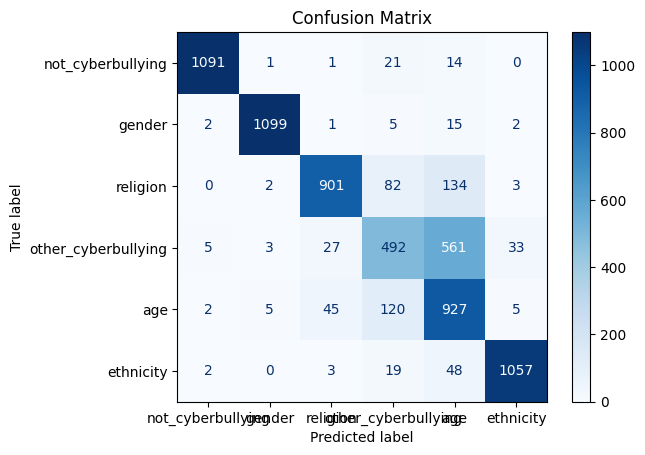

In [46]:
cm = confusion_matrix(y_val_enc, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_labels)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha='right')
plt.show()

This confusion matrix shows that XGBClassifier is indeed better at classifying age correctly, but struggles even more on other_cyberbullying.

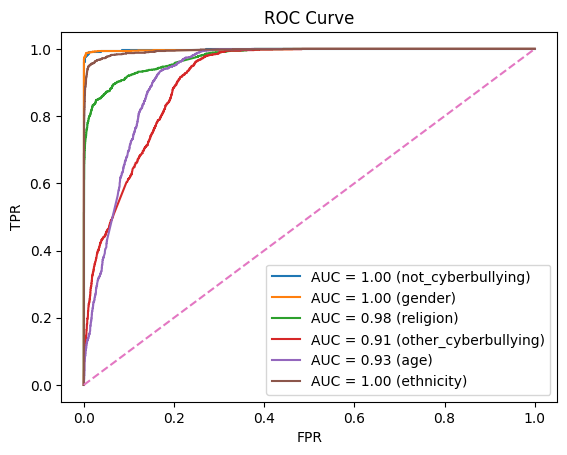

In [47]:
classes = list(set(y_val_enc))
y_bin = label_binarize(y_val_enc, classes=classes)
y_pred = best_xgbc.predict_proba(X_val_tfidf)

for i in range(len(classes)):
  fpr, tpr, _ = roc_curve(y_bin[:, i], y_pred[:, i])
  roc_auc = auc(fpr, tpr)
  plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f} ({target_labels[i]})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

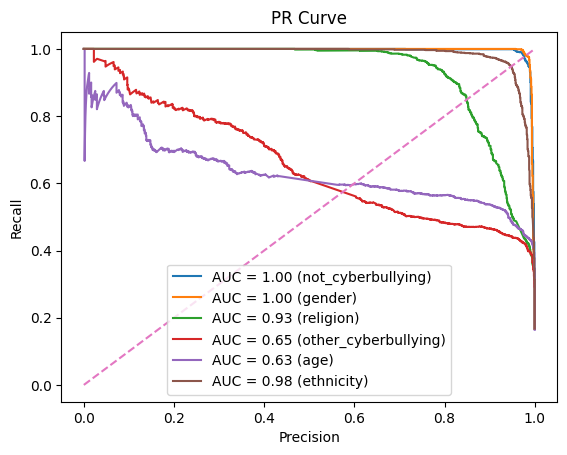

In [48]:
for i in range(len(classes)):
  precision, recall, _ = precision_recall_curve(y_bin[:, i], y_pred[:, i])
  pr_auc = auc(recall, precision)
  plt.plot(recall, precision, label=f"AUC = {pr_auc:.2f} ({target_labels[i]})")


plt.plot([0,1],[0,1],'--')
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.title("PR Curve")
plt.legend()
plt.show()

The situation is the same as on the previous PR AUC curve for logistic regression. The age and other cyberbullying classes showed substantially lower PR-AUC scores (0.63 and 0.65, respectively). PR AUC shows that the model have a great performance on every other classes.

## Conclusion

The models achieved strong performance on clear categories such as gender and ethnicity, with near-perfect ROC-AUC scores. However, it struggled with classes like age and other cyberbullying, as shown by lower PR-AUC values. Future improvements could include transformer-based models to better capture context.